# Example Pipeline

This would be a pipeline to perform the whole process in one of our files in the pipeline. Since we are going to be analyzing different sizes of the data, and different level of Illicit, we are going to create a standardized pipeline to perform every event for the project.

In [1]:
%pip install -q --no-cache-dir numpy==2.0.2 pandas==2.2.2

%pip install -q --no-cache-dir \
  torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 \
  --index-url https://download.pytorch.org/whl/cu121

%pip install -q --no-cache-dir torch-geometric

%pip install -q --no-cache-dir \
  pyg-lib -f https://data.pyg.org/whl/torch-2.3.0+cu121.html

%pip install -q --no-cache-dir xgboost catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.9/780.9 MB 380.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 379.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 400.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 400.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 419.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 375.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 369.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 408.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 420.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 346.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 395.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 417.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import numpy as np
import pandas as pd
import torch
import torch_geometric
import xgboost
import catboost

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("pyg:", torch_geometric.__version__)
print("xgboost:", xgboost.__version__)
print("catboost:", catboost.__version__)

numpy: 2.0.2
pandas: 2.2.2
torch: 2.3.1+cu121
cuda available: True
pyg: 2.7.0
xgboost: 3.2.0
catboost: 1.2.10


In [3]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import TransformerConv
from torch_geometric.data import Data
from torch_geometric.loader import LinkNeighborLoader
from sklearn.metrics import average_precision_score, roc_auc_score
from torch_geometric.loader import NeighborLoader
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt
import seaborn as sns
import random
import copy
from itertools import combinations
from pathlib import Path
import gc
from collections import Counter
import os
from datetime import datetime
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [4]:
# If you are running locally comment out this section. We ran our project using
# Google Colab Pro+, so we are going to keep this line for reproducibility.

from google.colab import drive
drive.mount('/content/drive')
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

Mounted at /content/drive


In [5]:
# Also change path is it is being run locally.
base_path = "/content/drive/MyDrive/dataset/HI-Small_Trans.csv"
PROJECT_ROOT = "/content/drive/MyDrive/dataset"
dataset = "HI-Small_Trans.csv"
CSV_PATH = PROJECT_ROOT + dataset

df = pd.read_csv(base_path)
print("Shape:", df.shape)
df.head()

Shape: (5078345, 11)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:20,10,8000EBD30,10,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022/09/01 00:20,3208,8000F4580,1,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022/09/01 00:00,3209,8000F4670,3209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022/09/01 00:02,12,8000F5030,12,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022/09/01 00:06,10,8000F5200,10,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


## EDA & Preprocessing

In [6]:
# Support functions
def plot_label_distribution(df, title):
    counts = df["Is Laundering"].value_counts()
    rates = df["Is Laundering"].value_counts(normalize=True)

    print(counts)
    print()
    print(rates)

    plt.figure()
    counts.plot(kind="bar")
    plt.title(title)
    plt.ylabel("Count")
    plt.show()

def null_summary(df):
    null_counts = df.isna().sum()

    summary = pd.DataFrame({
        "null_count": null_counts,
    })

    return summary[summary["null_count"] > 0]

def duplicate_check(df):
    total = len(df)
    dup_all = df.duplicated().sum()

    return {
        "total_rows": total,
        "duplicate_rows": dup_all,
        "duplicate_rate": dup_all / total
    }

def timestamp_summary(df, time_col="Timestamp"):
    ts = pd.to_datetime(df[time_col], errors="coerce")

    return {
        "min_time": ts.min(),
        "max_time": ts.max(),
        "null_timestamps": ts.isna().sum()
    }

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078345 entries, 0 to 5078344
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           object 
 1   From Bank           int64  
 2   Account             object 
 3   To Bank             int64  
 4   Account.1           object 
 5   Amount Received     float64
 6   Receiving Currency  object 
 7   Amount Paid         float64
 8   Payment Currency    object 
 9   Payment Format      object 
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 426.2+ MB


In [8]:
df.describe(include="all")

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
count,5078345,5.078345e+06,5078345,5.078345e+06,5078345,5.078345e+06,5078345,5.078345e+06,5078345,5078345,5.078345e+06
unique,15018,NaN,496995,NaN,420636,NaN,15,NaN,15,7,NaN
top,2022/09/01 00:04,NaN,100428660,NaN,100428660,NaN,US Dollar,NaN,US Dollar,Cheque,NaN
freq,11193,NaN,168672,NaN,1084,NaN,1879341,NaN,1895172,1864331,NaN
mean,NaN,4.573057e+04,NaN,6.574456e+04,NaN,5.988726e+06,NaN,4.509273e+06,NaN,NaN,1.019427e-03
std,NaN,8.176562e+04,NaN,8.409299e+04,NaN,1.037183e+09,NaN,8.697728e+08,NaN,NaN,3.191219e-02
min,NaN,1.000000e+00,NaN,1.000000e+00,NaN,1.000000e-06,NaN,1.000000e-06,NaN,NaN,0.000000e+00
25%,NaN,1.190000e+02,NaN,4.259000e+03,NaN,1.833700e+02,NaN,1.844800e+02,NaN,NaN,0.000000e+00
50%,NaN,9.679000e+03,NaN,2.156800e+04,NaN,1.411010e+03,NaN,1.414540e+03,NaN,NaN,0.000000e+00
75%,NaN,2.862800e+04,NaN,1.223320e+05,NaN,1.234627e+04,NaN,1.229784e+04,NaN,NaN,0.000000e+00


In [9]:
df['Is Laundering'].unique()

array([0, 1])

### Null & Duplicates

In [10]:
null_summary(df)

,null_count


In [11]:
duplicate_check(df)

{'total_rows': 5078345,
 'duplicate_rows': np.int64(9),
 'duplicate_rate': np.float64(1.7722309138114878e-06)}

In [12]:
# Clean duplicates
print(f"Shape before removing duplicates: {df.shape}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"New shape after removing duplicates: {df.shape}")

Shape before removing duplicates: (5078345, 11)
New shape after removing duplicates: (5078336, 11)


In [13]:
# Check for invalid account names
account_cols = [c for c in df.columns if "account" in c.lower()]

if len(account_cols) == 0:
    print("No account columns found (no columns containing 'account').")
else:
    # Basic validity rules:
    # - not null
    # - not empty/whitespace
    # - only allows letters, digits, underscore, hyphen, dot (customize if needed)
    allowed_pattern = r"^[A-Za-z0-9_.-]+$"

    invalid_summary = {}

    for c in account_cols:
        s = df[c].astype("string")

        is_null = s.isna()
        is_empty = s.str.strip().eq("")
        bad_chars = ~s.str.match(allowed_pattern, na=False)

        invalid_mask = is_null | is_empty | bad_chars
        invalid_count = int(invalid_mask.sum())

        invalid_summary[c] = {
            "invalid_count": invalid_count,
            "null_count": int(is_null.sum()),
            "empty_count": int(is_empty.sum()),
            "bad_char_count": int(bad_chars.sum())
        }

        print(f"\n[{c}] invalid rows: {invalid_count}")
        print("  null:", invalid_summary[c]["null_count"])
        print("  empty:", invalid_summary[c]["empty_count"])
        print("  bad_chars:", invalid_summary[c]["bad_char_count"])

        if invalid_count > 0:
            examples = df.loc[invalid_mask, c].astype("string").head(10).tolist()
            print("  examples:", examples)

    print("\nChecked account columns:", account_cols)


[Account] invalid rows: 0
  null: 0
  empty: 0
  bad_chars: 0

[Account.1] invalid rows: 0
  null: 0
  empty: 0
  bad_chars: 0

Checked account columns: ['Account', 'Account.1']


In [14]:
# Check for invalid transaction values

value_cols = [c for c in df.columns if any(k in c.lower() for k in ["amount", "value"])]

if len(value_cols) == 0:
    print("No transaction value columns found (no columns containing 'amount' or 'value').")
else:
    for c in value_cols:
        x = pd.to_numeric(df[c], errors="coerce")

        is_nan = x.isna()
        is_inf = np.isinf(x.to_numpy(dtype=float, copy=False))
        is_neg = x < 0
        is_zero = x == 0

        invalid_mask = is_nan | is_inf | is_neg

        print(f"\n[{c}]")
        print("  total rows:", len(df))
        print("  NaN after numeric coercion:", int(is_nan.sum()))
        print("  inf:", int(is_inf.sum()))
        print("  negative:", int(is_neg.sum()))
        print("  zero:", int(is_zero.sum()))
        print("  invalid (NaN/inf/negative):", int(invalid_mask.sum()))

        if int(invalid_mask.sum()) > 0:
            example_rows = df.loc[invalid_mask, [c]].head(10)
            print("  first invalid examples:")
            display(example_rows)

    print("\nChecked value columns:", value_cols)


[Amount Received]
  total rows: 5078336
  NaN after numeric coercion: 0
  inf: 0
  negative: 0
  zero: 0
  invalid (NaN/inf/negative): 0

[Amount Paid]
  total rows: 5078336
  NaN after numeric coercion: 0
  inf: 0
  negative: 0
  zero: 0
  invalid (NaN/inf/negative): 0

Checked value columns: ['Amount Received', 'Amount Paid']


### Distributions

Is Laundering
0    5073159
1       5177
Name: count, dtype: int64

Is Laundering
0    0.998981
1    0.001019
Name: proportion, dtype: float64


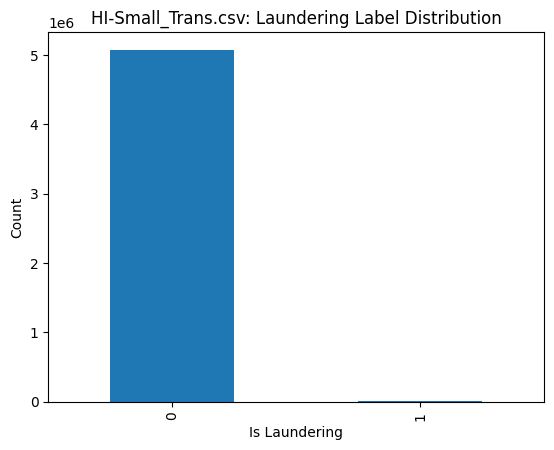

In [15]:
plot_label_distribution(df, dataset + ": Laundering Label Distribution")

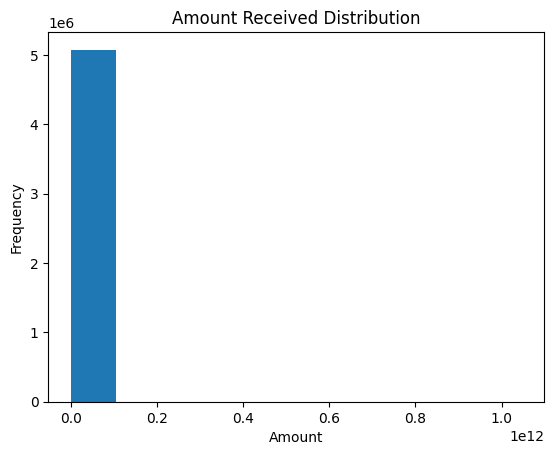

In [16]:
plt.hist(df["Amount Received"])
plt.title("Amount Received Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

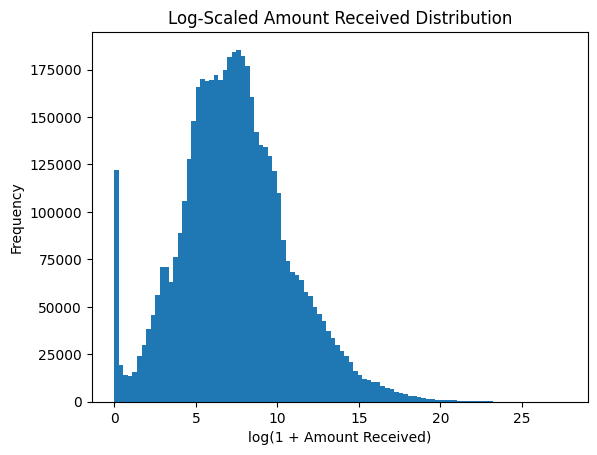

In [17]:
amt = pd.to_numeric(df["Amount Received"], errors="coerce")
df["Log Amount Received"] = np.log1p(amt)

plt.figure()
plt.hist(df["Log Amount Received"], bins=100)
plt.title("Log-Scaled Amount Received Distribution")
plt.xlabel("log(1 + Amount Received)")
plt.ylabel("Frequency")
plt.show()

In [18]:
ct = pd.crosstab(
    df["Payment Currency"],
    df["Is Laundering"]
)

ct["total"] = ct[0] + ct[1]
ct["laundered_%"] = ct[1] / ct["total"] * 100

ct.sort_values("laundered_%", ascending=False)

Is Laundering,0,1,total,laundered_%
Payment Currency,,,,
Saudi Riyal,88640,374,89014,0.420159
Euro,1166924,1372,1168296,0.117436
US Dollar,1893257,1912,1895169,0.100888
Yen,155054,155,155209,0.099865
Australian Dollar,136642,127,136769,0.092857
Canadian Dollar,139914,128,140042,0.091401
Rupee,190035,167,190202,0.087801
Yuan,213568,184,213752,0.086081
Ruble,155045,133,155178,0.085708


In [19]:
numeric_cols = df.select_dtypes(include=["int64", "float64"])

numeric_cols.corr()

,From Bank,To Bank,Amount Received,Amount Paid,Is Laundering,Log Amount Received
From Bank,1.000000,0.289930,-0.000909,-0.000442,-0.000230,-0.039154
To Bank,0.289930,1.000000,-0.000523,0.000406,-0.005723,-0.012479
Amount Received,-0.000909,-0.000523,1.000000,0.843147,0.000929,0.027186
Amount Paid,-0.000442,0.000406,0.843147,1.000000,0.001162,0.023790
Is Laundering,-0.000230,-0.005723,0.000929,0.001162,1.000000,0.015683
Log Amount Received,-0.039154,-0.012479,0.027186,0.023790,0.015683,1.000000


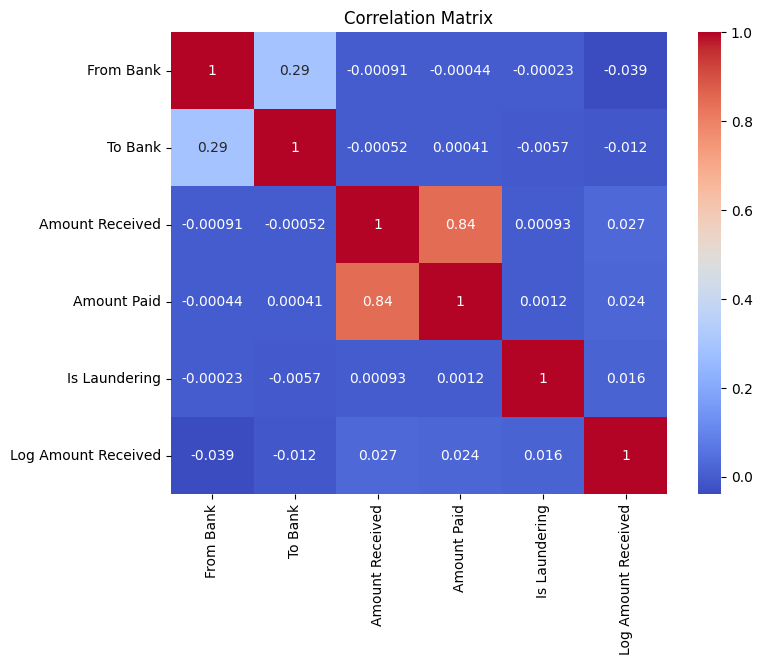

In [20]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### Datetime Preprocessing

In [21]:
timestamp_summary(df)

{'min_time': Timestamp('2022-09-01 00:00:00'),
 'max_time': Timestamp('2022-09-18 16:18:00'),
 'null_timestamps': np.int64(0)}

In [22]:
# Setup for date data preprocessing

TS_COL = "Timestamp"
LABEL_COL = "Is Laundering"

TS_FORMAT = "%Y/%m/%d %H:%M"

# Use True for Large
USE_STREAMING = False
CHUNKSIZE = 2_000_000


def _coerce_label_to_int(series):
    return pd.to_numeric(series.astype(str).str.strip(), errors="coerce").fillna(0).astype(int)


def _time_aggs_from_df(df_in, ts_col=TS_COL, label_col=LABEL_COL, ts_format=TS_FORMAT):
    y = _coerce_label_to_int(df_in[label_col]).to_numpy(dtype=np.int8)

    if ts_format is None:
        ts = pd.to_datetime(df_in[ts_col], errors="coerce")
    else:
        ts = pd.to_datetime(df_in[ts_col], format=ts_format, errors="coerce")

    mask = ts.notna().to_numpy()
    bad_ts = int((~mask).sum())

    ts = ts[mask]
    y = y[mask]

    hour = ts.dt.hour.to_numpy(dtype=np.int16)
    dow = ts.dt.dayofweek.to_numpy(dtype=np.int16)  # Mon=0..Sun=6

    hour_total = np.bincount(hour, minlength=24).astype(np.int64)
    hour_pos   = np.bincount(hour, weights=y, minlength=24).astype(np.int64)

    dow_total = np.bincount(dow, minlength=7).astype(np.int64)
    dow_pos   = np.bincount(dow, weights=y, minlength=7).astype(np.int64)

    idx = dow * 24 + hour
    hd_total = np.bincount(idx, minlength=7*24).reshape(7, 24).astype(np.int64)
    hd_pos   = np.bincount(idx, weights=y, minlength=7*24).reshape(7, 24).astype(np.int64)

    return {
        "hour_total": hour_total, "hour_pos": hour_pos,
        "dow_total": dow_total,   "dow_pos": dow_pos,
        "hd_total": hd_total,     "hd_pos": hd_pos,
        "total_rows": int(mask.sum()),
        "bad_ts": bad_ts
    }


def _time_aggs_streaming(csv_path, chunksize=CHUNKSIZE, ts_col=TS_COL, label_col=LABEL_COL, ts_format=TS_FORMAT):
    hour_total = np.zeros(24, dtype=np.int64)
    hour_pos   = np.zeros(24, dtype=np.int64)

    dow_total  = np.zeros(7, dtype=np.int64)
    dow_pos    = np.zeros(7, dtype=np.int64)

    hd_total   = np.zeros((7, 24), dtype=np.int64)
    hd_pos     = np.zeros((7, 24), dtype=np.int64)

    total_rows = 0
    bad_ts = 0

    usecols = [ts_col, label_col]

    for chunk in pd.read_csv(csv_path, usecols=usecols, chunksize=chunksize):
        total_rows += len(chunk)

        y = _coerce_label_to_int(chunk[label_col]).to_numpy(dtype=np.int8)

        if ts_format is None:
            ts = pd.to_datetime(chunk[ts_col], errors="coerce")
        else:
            ts = pd.to_datetime(chunk[ts_col], format=ts_format, errors="coerce")

        mask = ts.notna().to_numpy()
        if not mask.all():
            bad_ts += int((~mask).sum())

        ts = ts[mask]
        y  = y[mask]

        hour = ts.dt.hour.to_numpy(dtype=np.int16)
        dow  = ts.dt.dayofweek.to_numpy(dtype=np.int16)

        hour_total += np.bincount(hour, minlength=24)
        hour_pos   += np.bincount(hour, weights=y, minlength=24).astype(np.int64)

        dow_total += np.bincount(dow, minlength=7)
        dow_pos   += np.bincount(dow, weights=y, minlength=7).astype(np.int64)

        idx = dow * 24 + hour
        flat_total = np.bincount(idx, minlength=7*24).reshape(7, 24)
        flat_pos   = np.bincount(idx, weights=y, minlength=7*24).reshape(7, 24).astype(np.int64)

        hd_total += flat_total
        hd_pos   += flat_pos

    return {
        "hour_total": hour_total, "hour_pos": hour_pos,
        "dow_total": dow_total,   "dow_pos": dow_pos,
        "hd_total": hd_total,     "hd_pos": hd_pos,
        "total_rows": int(total_rows),
        "bad_ts": int(bad_ts)
    }

In [23]:
if USE_STREAMING:
    agg = _time_aggs_streaming(CSV_PATH, chunksize=CHUNKSIZE, ts_format=TS_FORMAT)
else:
    agg = _time_aggs_from_df(df, ts_format=TS_FORMAT)

hour_total = agg["hour_total"]
hour_pos   = agg["hour_pos"]
dow_total  = agg["dow_total"]
dow_pos    = agg["dow_pos"]
hd_total   = agg["hd_total"]
hd_pos     = agg["hd_pos"]

print("Temporal EDA for:", dataset)
print("Rows used (valid timestamps):", agg["total_rows"])
print("Bad/unparsed timestamps:", agg["bad_ts"])
print("Overall laundering rate:", float(hour_pos.sum() / max(hour_total.sum(), 1)))

Temporal EDA for: HI-Small_Trans.csv
Rows used (valid timestamps): 5078336
Bad/unparsed timestamps: 0
Overall laundering rate: 0.0010194284111961084


In [24]:
hour_df = pd.DataFrame({
    "hour": np.arange(24),
    "tx_count": hour_total,
    "laundering_count": hour_pos,
    "laundering_rate": hour_pos / np.maximum(hour_total, 1)
})

dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_df = pd.DataFrame({
    "dow": np.arange(7),
    "day": dow_names,
    "tx_count": dow_total,
    "laundering_count": dow_pos,
    "laundering_rate": dow_pos / np.maximum(dow_total, 1)
})

hd_rate = hd_pos / np.maximum(hd_total, 1)

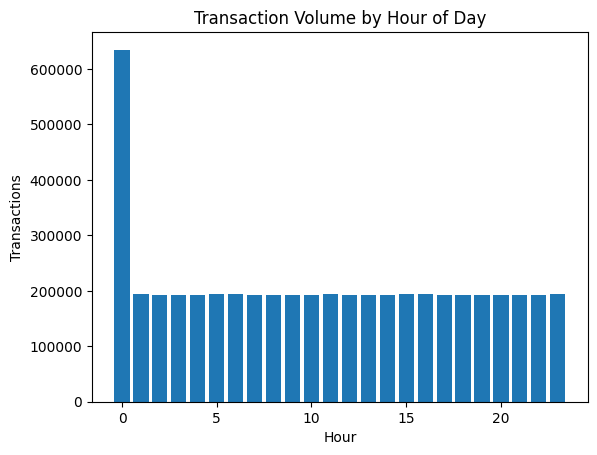

In [25]:
plt.figure()
plt.bar(hour_df["hour"], hour_df["tx_count"])
plt.title("Transaction Volume by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Transactions")
plt.show()

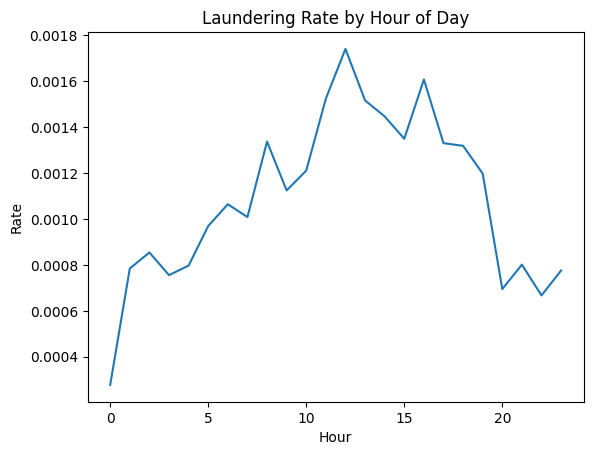

In [26]:
plt.figure()
plt.plot(hour_df["hour"], hour_df["laundering_rate"])
plt.title("Laundering Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Rate")
plt.show()

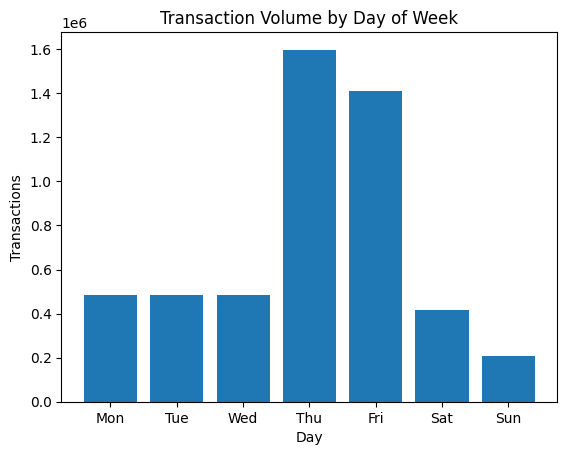

In [27]:
plt.figure()
plt.bar(dow_df["day"], dow_df["tx_count"])
plt.title("Transaction Volume by Day of Week")
plt.xlabel("Day")
plt.ylabel("Transactions")
plt.show()

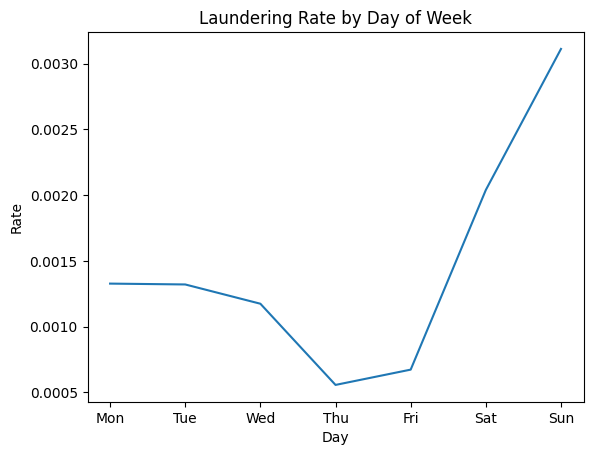

In [28]:
plt.figure()
plt.plot(dow_df["day"], dow_df["laundering_rate"])
plt.title("Laundering Rate by Day of Week")
plt.xlabel("Day")
plt.ylabel("Rate")
plt.show()

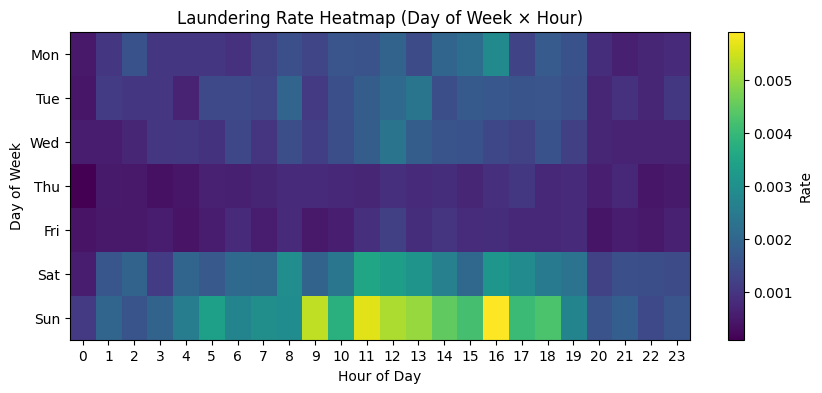

In [29]:
plt.figure(figsize=(10, 4))
plt.imshow(hd_rate, aspect="auto", interpolation="nearest")
plt.title("Laundering Rate Heatmap (Day of Week × Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.xticks(np.arange(24), np.arange(24))
plt.yticks(np.arange(7), dow_names)
plt.colorbar(label="Rate")
plt.show()

In [30]:
if TS_FORMAT is None:
    ts = pd.to_datetime(df[TS_COL], errors="coerce")
else:
    ts = pd.to_datetime(df[TS_COL], format=TS_FORMAT, errors="coerce")

df["_ts"] = ts
df["tx_hour"] = df["_ts"].dt.hour.astype("Int16")
df["tx_dow"] = df["_ts"].dt.dayofweek.astype("Int16")     # Mon=0..Sun=6
df["tx_month"] = df["_ts"].dt.month.astype("Int16")
df["tx_day"] = df["_ts"].dt.day.astype("Int16")
df["tx_date"] = df["_ts"].dt.date                       # python date
df["tx_is_weekend"] = df["tx_dow"].isin([5, 6]).astype("Int8")
df["tx_hour_sin"] = np.sin(2 * np.pi * df["tx_hour"].fillna(0) / 24.0)
df["tx_hour_cos"] = np.cos(2 * np.pi * df["tx_hour"].fillna(0) / 24.0)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5078336 entries, 0 to 5078335
Data columns (total 21 columns):
 #   Column               Dtype         
---  ------               -----         
 0   Timestamp            object        
 1   From Bank            int64         
 2   Account              object        
 3   To Bank              int64         
 4   Account.1            object        
 5   Amount Received      float64       
 6   Receiving Currency   object        
 7   Amount Paid          float64       
 8   Payment Currency     object        
 9   Payment Format       object        
 10  Is Laundering        int64         
 11  Log Amount Received  float64       
 12  _ts                  datetime64[ns]
 13  tx_hour              Int16         
 14  tx_dow               Int16         
 15  tx_month             Int16         
 16  tx_day               Int16         
 17  tx_date              object        
 18  tx_is_weekend        Int8          
 19  tx_hour_sin          

In [32]:
df.describe(include="all")

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Log Amount Received,_ts,tx_hour,tx_dow,tx_month,tx_day,tx_date,tx_is_weekend,tx_hour_sin,tx_hour_cos
count,5078336,5.078336e+06,5078336,5.078336e+06,5078336,5.078336e+06,5078336,5.078336e+06,5078336,5078336,5.078336e+06,5.078336e+06,5078336,5078336.0,5078336.0,5078336.0,5078336.0,5078336,5078336.0,5078336.0,5078336.0
unique,15018,NaN,496995,NaN,420636,NaN,15,NaN,15,7,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,18,<NA>,<NA>,<NA>
top,2022/09/01 00:04,NaN,100428660,NaN,100428660,NaN,US Dollar,NaN,US Dollar,Cheque,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,2022-09-01,<NA>,<NA>,<NA>
freq,11193,NaN,168672,NaN,1084,NaN,1879341,NaN,1895169,1864331,NaN,NaN,NaN,<NA>,<NA>,<NA>,<NA>,1114919,<NA>,<NA>,<NA>
mean,NaN,4.573058e+04,NaN,6.574461e+04,NaN,5.988737e+06,NaN,4.509281e+06,NaN,NaN,1.019428e-03,7.419110e+00,2022-09-05 07:16:07.855403520,10.492454,2.993643,9.0,4.846101,NaN,0.12279,0.000563,0.086657
min,NaN,1.000000e+00,NaN,1.000000e+00,NaN,1.000000e-06,NaN,1.000000e-06,NaN,NaN,0.000000e+00,9.999995e-07,2022-09-01 00:00:00,0.0,0.0,9.0,1.0,NaN,0.0,-1.0,-1.0
25%,NaN,1.190000e+02,NaN,4.259000e+03,NaN,1.833700e+02,NaN,1.844800e+02,NaN,NaN,0.000000e+00,5.216945e+00,2022-09-02 04:32:00,4.0,2.0,9.0,2.0,NaN,0.0,-0.707107,-0.707107
50%,NaN,9.679000e+03,NaN,2.156800e+04,NaN,1.411040e+03,NaN,1.414570e+03,NaN,NaN,0.000000e+00,7.252791e+00,2022-09-05 12:16:00,10.0,3.0,9.0,5.0,NaN,0.0,0.0,0.258819
75%,NaN,2.862800e+04,NaN,1.223320e+05,NaN,1.234630e+04,NaN,1.229815e+04,NaN,NaN,0.000000e+00,9.421193e+00,2022-09-08 03:13:00,17.0,4.0,9.0,8.0,NaN,0.0,0.707107,0.866025
max,NaN,3.563030e+05,NaN,3.562940e+05,NaN,1.046302e+12,NaN,1.046302e+12,NaN,NaN,1.000000e+00,2.767628e+01,2022-09-18 16:18:00,23.0,6.0,9.0,18.0,NaN,1.0,1.0,1.0


## Feature Engineering

### Preparation for model

In [33]:
def run_epoch_train(model, loader, opt, crit, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for batch in loader:
        batch = batch.to(device)

        logits = model(batch)
        y = batch.edge_label.to(device)

        loss = crit(logits, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        bs = y.numel()
        total_loss += float(loss.item()) * bs

        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(bs)

    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)
    return avg_loss, acc


@torch.no_grad()
def run_epoch_eval(model, loader, crit, device, max_batches=None, threshold=0.5):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    probs_all = []
    ys_all = []

    for i, batch in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break

        batch = batch.to(device)

        logits = model(batch)
        y = batch.edge_label.to(device)

        loss = crit(logits, y)

        bs = y.numel()
        total_loss += float(loss.item()) * bs

        pred = logits.argmax(dim=1)
        correct += int((pred == y).sum().item())
        total += int(bs)

        prob1 = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
        probs_all.append(prob1)
        ys_all.append(y.detach().cpu().numpy())

    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)

    ys = np.concatenate(ys_all) if ys_all else np.array([])
    ps = np.concatenate(probs_all) if probs_all else np.array([])

    if ys.size > 0 and len(np.unique(ys)) > 1:
        pr_auc = average_precision_score(ys, ps)
        roc_auc = roc_auc_score(ys, ps)

        yhat = (ps >= threshold).astype(int)
        cm = confusion_matrix(ys, yhat, labels=[0, 1])
    else:
        pr_auc = np.nan
        roc_auc = np.nan
        yhat = np.array([])
        cm = np.array([[0, 0], [0, 0]])

    pos_rate = float(ys.mean()) if ys.size > 0 else np.nan

    return avg_loss, acc, pos_rate, pr_auc, roc_auc, cm, ys, ps


def plot_confusion_matrix_from_array(cm, title):
    fig, ax = plt.subplots(figsize=(5, 4))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    plt.show()

In [34]:
def build_base_graph(df):
    src_key = df["From Bank"].astype(str) + "|" + df["Account"].astype(str)
    dst_key = df["To Bank"].astype(str) + "|" + df["Account.1"].astype(str)

    all_keys = pd.concat([src_key, dst_key], ignore_index=True)
    codes, uniques = pd.factorize(all_keys, sort=False)

    E = len(src_key)
    src = codes[:E].astype("int64")
    dst = codes[E:].astype("int64")
    num_nodes = len(uniques)

    edge_index = torch.tensor(np.vstack([src, dst]), dtype=torch.long)
    y_edge = pd.to_numeric(df["Is Laundering"], errors="coerce").fillna(0).astype("int64").to_numpy()
    y_edge_t = torch.tensor(y_edge, dtype=torch.long)

    return edge_index, y_edge_t, num_nodes


def make_fixed_edge_split(num_edges, train_frac=0.70, val_frac=0.10, seed=42):
    g = torch.Generator()
    g.manual_seed(seed)

    edge_ids = torch.arange(num_edges, dtype=torch.long)
    perm = edge_ids[torch.randperm(edge_ids.numel(), generator=g)]

    n_train = int(train_frac * len(perm))
    n_val = int(val_frac * len(perm))

    train_eids = perm[:n_train]
    val_eids = perm[n_train:n_train + n_val]
    test_eids = perm[n_train + n_val:]

    return train_eids, val_eids, test_eids


edge_index, y_edge_t, num_nodes = build_base_graph(df)
train_eids, val_eids, test_eids = make_fixed_edge_split(edge_index.size(1), seed=42)

print("num_nodes:", num_nodes)
print("num_edges:", edge_index.size(1))
print("split sizes -> train:", len(train_eids), "val:", len(val_eids), "test:", len(test_eids))


num_nodes: 515088
num_edges: 5078336
split sizes -> train: 3554835 val: 507833 test: 1015668


### Feature Groups

In [35]:
FEATURE_GROUPS = {
    "raw_amounts": [
        "Amount Received",
        "Amount Paid",
        "Log Amount Received",
    ],
    "currencies": [
        "Receiving Currency",
        "Payment Currency",
    ],
    "payment_format": [
        "Payment Format",
    ],
    "time_basic": [
        "tx_dow",
        "tx_is_weekend",
    ],
    "time_cyclical": [
        "tx_hour_sin",
        "tx_hour_cos",
    ],
    "time_trend": [
        "_ts",
    ]
}

FEATURE_GROUPS = {
    group: [c for c in cols if c in df.columns]
    for group, cols in FEATURE_GROUPS.items()
}
FEATURE_GROUPS = {
    group: cols for group, cols in FEATURE_GROUPS.items()
    if len(cols) > 0
}

print("Usable feature groups:")
for k, v in FEATURE_GROUPS.items():
    print(f"{k}: {v}")

Usable feature groups:
raw_amounts: ['Amount Received', 'Amount Paid', 'Log Amount Received']
currencies: ['Receiving Currency', 'Payment Currency']
payment_format: ['Payment Format']
time_basic: ['tx_dow', 'tx_is_weekend']
time_cyclical: ['tx_hour_sin', 'tx_hour_cos']
time_trend: ['_ts']


In [36]:
CATEGORICAL_COLS = {
    "Receiving Currency",
    "Payment Currency",
    "Payment Format",
}

SPECIAL_DOW_COL = "tx_dow"
SPECIAL_TS_COLS = {"_ts", "Timestamp_norm"}

In [37]:
def encode_numeric_column(series):
    vals = pd.to_numeric(series, errors="coerce").fillna(0).astype(np.float32).to_numpy()
    if vals.size > 0:
        vmax = np.nanmax(np.abs(vals))
        if np.isfinite(vmax) and vmax > 0:
            vals = vals / vmax
    return vals.reshape(-1, 1), [series.name]


def encode_categorical_column(series):
    vals = series.astype(str).fillna("MISSING")
    uniq = pd.Index(vals.unique())
    if len(uniq) == 0:
        return np.zeros((len(series), 1), dtype=np.float32), [f"{series.name}__EMPTY"]

    codes = pd.Categorical(vals, categories=uniq).codes
    onehot = np.eye(len(uniq), dtype=np.float32)[codes]
    col_names = [f"{series.name}__{u}" for u in uniq]
    return onehot.astype(np.float32), col_names


def encode_dow_column(series):
    dow = pd.to_numeric(series, errors="coerce").fillna(0).astype(np.int64).to_numpy()
    dow = np.clip(dow, 0, 6)
    onehot = np.eye(7, dtype=np.float32)[dow]
    col_names = [f"tx_dow_{i}" for i in range(7)]
    return onehot.astype(np.float32), col_names


def encode_ts_column(series):
    ts = pd.to_datetime(series, errors="coerce")
    if ts.notna().sum() == 0:
        vals = np.zeros(len(series), dtype=np.float32)
    else:
        ts = ts.fillna(ts.dropna().min())
        t0 = ts.min()
        vals = (ts - t0).dt.total_seconds().astype(np.float32).to_numpy()
        vmax = float(np.max(vals)) if len(vals) > 0 else 0.0
        if vmax > 0:
            vals = vals / vmax
    return vals.reshape(-1, 1).astype(np.float32), [f"{series.name}_norm"]


def build_edge_attr_from_feature_cols(df, feature_cols):
    parts = []
    feature_names = []

    for col in feature_cols:
        if col not in df.columns:
            continue

        s = df[col]

        if col in SPECIAL_TS_COLS:
            arr, names = encode_ts_column(s)
        elif col == SPECIAL_DOW_COL:
            arr, names = encode_dow_column(s)
        elif col in CATEGORICAL_COLS:
            arr, names = encode_categorical_column(s)
        else:
            arr, names = encode_numeric_column(s)

        parts.append(arr)
        feature_names.extend(names)

    if len(parts) == 0:
        edge_attr = np.zeros((len(df), 1), dtype=np.float32)
        feature_names = ["dummy_feature"]

    else:
        edge_attr = np.concatenate(parts, axis=1).astype(np.float32)

    return edge_attr, feature_names

In [38]:
def make_loaders_for_feature_cols(
    df,
    edge_index,
    y_edge_t,
    num_nodes,
    train_eids,
    val_eids,
    test_eids,
    feature_cols,
    num_neighbors=[15, 10],
    batch_size=4096,
):
    edge_attr_np, expanded_feature_names = build_edge_attr_from_feature_cols(df, feature_cols)
    edge_attr_t = torch.tensor(edge_attr_np, dtype=torch.float32)

    data = Data(num_nodes=num_nodes, edge_index=edge_index, edge_attr=edge_attr_t)

    train_loader = LinkNeighborLoader(
        data,
        edge_label_index=edge_index[:, train_eids],
        edge_label=y_edge_t[train_eids],
        num_neighbors=num_neighbors,
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = LinkNeighborLoader(
        data,
        edge_label_index=edge_index[:, val_eids],
        edge_label=y_edge_t[val_eids],
        num_neighbors=num_neighbors,
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = LinkNeighborLoader(
        data,
        edge_label_index=edge_index[:, test_eids],
        edge_label=y_edge_t[test_eids],
        num_neighbors=num_neighbors,
        batch_size=batch_size,
        shuffle=False
    )

    return data, train_loader, val_loader, test_loader, expanded_feature_names

In [39]:
class EdgeAwareGNN(nn.Module):
    def __init__(self, num_nodes, hidden=128, edge_dim=1):
        super().__init__()
        self.emb = nn.Embedding(num_nodes, hidden)
        self.conv1 = TransformerConv(hidden, hidden, edge_dim=edge_dim)
        self.conv2 = TransformerConv(hidden, hidden, edge_dim=edge_dim)
        self.mlp = nn.Sequential(
            nn.Linear(hidden * 4, 256),
            nn.ReLU(),
            nn.Linear(256, 2)
        )

    def forward(self, batch):
        x = self.emb(batch.n_id)
        x = F.relu(self.conv1(x, batch.edge_index, batch.edge_attr))
        x = self.conv2(x, batch.edge_index, batch.edge_attr)

        src_i = batch.edge_label_index[0]
        dst_i = batch.edge_label_index[1]
        hs = x[src_i]
        hd = x[dst_i]
        h = torch.cat([hs, hd, hs * hd, (hs - hd).abs()], dim=-1)
        return self.mlp(h)

In [40]:
def train_and_score_feature_set(
    set_name,
    feature_cols,
    df,
    edge_index,
    y_edge_t,
    num_nodes,
    train_eids,
    val_eids,
    test_eids,
    device,
    hidden=128,
    lr=2e-3,
    epochs=3,
    batch_size=4096,
    num_neighbors=[15, 10],
    eval_test=False,
    max_eval_batches=200,
    threshold=0.5,
):
    data, train_loader, val_loader, test_loader, expanded_feature_names = make_loaders_for_feature_cols(
        df=df,
        edge_index=edge_index,
        y_edge_t=y_edge_t,
        num_nodes=num_nodes,
        train_eids=train_eids,
        val_eids=val_eids,
        test_eids=test_eids,
        feature_cols=feature_cols,
        num_neighbors=num_neighbors,
        batch_size=batch_size,
    )

    edge_dim = data.edge_attr.size(1)

    model = EdgeAwareGNN(
        num_nodes=num_nodes,
        hidden=hidden,
        edge_dim=edge_dim
    ).to(device)

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()

    history = []
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch_train(model, train_loader, opt, crit, device)

        va_loss, va_acc, _, va_pr, va_roc, va_cm, _, _ = run_epoch_eval(
            model,
            val_loader,
            crit,
            device,
            max_batches=max_eval_batches,
            threshold=threshold,
        )

        history.append({
            "epoch": epoch,
            "train_loss": tr_loss,
            "train_acc": tr_acc,
            "val_loss": va_loss,
            "val_acc": va_acc,
            "val_pr_auc": va_pr,
            "val_roc_auc": va_roc,
            "val_confusion_matrix": va_cm,
        })

        print(
            f"[{set_name}] epoch {epoch} | "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
            f"val PR {va_pr:.4f} | val ROC {va_roc:.4f}"
        )

    _, _, val_pos_rate, val_pr_auc, val_roc_auc, val_cm, val_y, val_p = run_epoch_eval(
        model,
        val_loader,
        crit,
        device,
        max_batches=max_eval_batches,
        threshold=threshold,
    )

    result = {
        "feature_set": set_name,
        "feature_cols": feature_cols,
        "expanded_feature_names": expanded_feature_names,
        "num_raw_features": len(feature_cols),
        "num_features_after_encoding": edge_dim,
        "val_pos_rate": val_pos_rate,
        "val_pr_auc": val_pr_auc,
        "val_roc_auc": val_roc_auc,
        "val_confusion_matrix": val_cm,
        "val_y_true": val_y,
        "val_y_prob": val_p,
        "history": history,
        "model_state_dict": copy.deepcopy(model.state_dict()),
    }

    if eval_test:
        _, _, test_pos_rate, test_pr_auc, test_roc_auc, test_cm, test_y, test_p = run_epoch_eval(
            model,
            test_loader,
            crit,
            device,
            max_batches=max_eval_batches,
            threshold=threshold,
        )
        result["test_pos_rate"] = test_pos_rate
        result["test_pr_auc"] = test_pr_auc
        result["test_roc_auc"] = test_roc_auc
        result["test_confusion_matrix"] = test_cm
        result["test_y_true"] = test_y
        result["test_y_prob"] = test_p

    return result

In [41]:
RAW_BASE = ["raw_amounts", "currencies", "payment_format"]

FEATURE_SET_LIBRARY = {
    "raw_only": RAW_BASE,
    "time_only_current_engineered": ["raw_amounts", "time_basic", "time_cyclical", "time_trend"],
    "raw_plus_time_basic": RAW_BASE + ["time_basic"],
    "raw_plus_time_cyclical": RAW_BASE + ["time_cyclical"],
    "raw_plus_all_time": RAW_BASE + ["time_basic", "time_cyclical", "time_trend"],
}

FEATURE_SET_LIBRARY = {
    name: [g for g in groups if g in FEATURE_GROUPS]
    for name, groups in FEATURE_SET_LIBRARY.items()
}
FEATURE_SET_LIBRARY = {
    name: groups for name, groups in FEATURE_SET_LIBRARY.items()
    if len(groups) > 0
}

for k, v in FEATURE_SET_LIBRARY.items():
    print(f"{k}: {v}")

raw_only: ['raw_amounts', 'currencies', 'payment_format']
time_only_current_engineered: ['raw_amounts', 'time_basic', 'time_cyclical', 'time_trend']
raw_plus_time_basic: ['raw_amounts', 'currencies', 'payment_format', 'time_basic']
raw_plus_time_cyclical: ['raw_amounts', 'currencies', 'payment_format', 'time_cyclical']
raw_plus_all_time: ['raw_amounts', 'currencies', 'payment_format', 'time_basic', 'time_cyclical', 'time_trend']


In [42]:
def flatten_feature_groups(group_list, feature_groups):
    cols = []
    for g in group_list:
        cols.extend(feature_groups[g])
    # preserve order while removing duplicates
    return list(dict.fromkeys(cols))


def generate_feature_set_library_from_groups(
    feature_groups,
    min_groups=1,
    max_groups=3,
    required_groups=None,
):
    group_names = list(feature_groups.keys())
    required_groups = required_groups or []

    library = {}
    for r in range(min_groups, max_groups + 1):
        for combo in combinations(group_names, r):
            combo = list(combo)

            if required_groups and not set(required_groups).issubset(set(combo)):
                continue

            set_name = " + ".join(combo)
            library[set_name] = combo

    return library

In [43]:
SEARCH_LIBRARY = generate_feature_set_library_from_groups(
    feature_groups=FEATURE_GROUPS,
    min_groups=3,
    max_groups=5,
    required_groups=RAW_BASE
)

print("Total feature sets to evaluate:", len(SEARCH_LIBRARY))
for k, v in SEARCH_LIBRARY.items():
    print(f"{k}: {v}")

Total feature sets to evaluate: 7
raw_amounts + currencies + payment_format: ['raw_amounts', 'currencies', 'payment_format']
raw_amounts + currencies + payment_format + time_basic: ['raw_amounts', 'currencies', 'payment_format', 'time_basic']
raw_amounts + currencies + payment_format + time_cyclical: ['raw_amounts', 'currencies', 'payment_format', 'time_cyclical']
raw_amounts + currencies + payment_format + time_trend: ['raw_amounts', 'currencies', 'payment_format', 'time_trend']
raw_amounts + currencies + payment_format + time_basic + time_cyclical: ['raw_amounts', 'currencies', 'payment_format', 'time_basic', 'time_cyclical']
raw_amounts + currencies + payment_format + time_basic + time_trend: ['raw_amounts', 'currencies', 'payment_format', 'time_basic', 'time_trend']
raw_amounts + currencies + payment_format + time_cyclical + time_trend: ['raw_amounts', 'currencies', 'payment_format', 'time_cyclical', 'time_trend']


In [44]:
EPOCHS = 3
HIDDEN = 128
LR = 2e-3
BATCH_SIZE = 4096
NUM_NEIGHBORS = [15, 10]
MAX_EVAL_BATCHES = 200

EVAL_TEST_DURING_SEARCH = False

all_results = []

for set_name, group_list in SEARCH_LIBRARY.items():
    feature_cols = flatten_feature_groups(group_list, FEATURE_GROUPS)
    feature_cols = [c for c in feature_cols if c in df.columns]

    if len(feature_cols) == 0:
        print(f"Skipping {set_name} because no usable columns were found.")
        continue

    print("\n" + "=" * 90)
    print("Running feature set:", set_name)
    print("Groups:", group_list)
    print("Columns:", feature_cols)

    try:
        result = train_and_score_feature_set(
            set_name=set_name,
            feature_cols=feature_cols,
            df=df,
            edge_index=edge_index,
            y_edge_t=y_edge_t,
            num_nodes=num_nodes,
            train_eids=train_eids,
            val_eids=val_eids,
            test_eids=test_eids,
            device=device,
            hidden=HIDDEN,
            lr=LR,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            num_neighbors=NUM_NEIGHBORS,
            eval_test=EVAL_TEST_DURING_SEARCH,
            max_eval_batches=MAX_EVAL_BATCHES,
        )
        all_results.append(result)

    except Exception as e:
        print(f"Failed on {set_name}: {e}")
        all_results.append({
            "feature_set": set_name,
            "feature_cols": feature_cols,
            "expanded_feature_names": None,
            "num_raw_features": len(feature_cols),
            "num_features_after_encoding": None,
            "val_pos_rate": np.nan,
            "val_pr_auc": np.nan,
            "val_roc_auc": np.nan,
            "error": str(e)
        })


Running feature set: raw_amounts + currencies + payment_format
Groups: ['raw_amounts', 'currencies', 'payment_format']
Columns: ['Amount Received', 'Amount Paid', 'Log Amount Received', 'Receiving Currency', 'Payment Currency', 'Payment Format']
[raw_amounts + currencies + payment_format] epoch 1 | train loss 0.0078 acc 0.9987 | val loss 0.0049 acc 0.9992 | val PR 0.4009 | val ROC 0.9132
[raw_amounts + currencies + payment_format] epoch 2 | train loss 0.0038 acc 0.9993 | val loss 0.0049 acc 0.9992 | val PR 0.4073 | val ROC 0.9134
[raw_amounts + currencies + payment_format] epoch 3 | train loss 0.0028 acc 0.9994 | val loss 0.0057 acc 0.9992 | val PR 0.4078 | val ROC 0.9116

Running feature set: raw_amounts + currencies + payment_format + time_basic
Groups: ['raw_amounts', 'currencies', 'payment_format', 'time_basic']
Columns: ['Amount Received', 'Amount Paid', 'Log Amount Received', 'Receiving Currency', 'Payment Currency', 'Payment Format', 'tx_dow', 'tx_is_weekend']
[raw_amounts + cu

In [45]:
results_rows = []
for r in all_results:
    row = {
        "feature_set": r.get("feature_set"),
        "num_raw_features": r.get("num_raw_features"),
        "num_features_after_encoding": r.get("num_features_after_encoding"),
        "val_pr_auc": r.get("val_pr_auc"),
        "val_roc_auc": r.get("val_roc_auc"),
        "error": r.get("error", None),
    }

    if "test_pr_auc" in r:
        row["test_pr_auc"] = r.get("test_pr_auc")
        row["test_roc_auc"] = r.get("test_roc_auc")

    results_rows.append(row)

results_df = pd.DataFrame(results_rows).sort_values(
    by="val_pr_auc",
    ascending=False,
    na_position="last"
).reset_index(drop=True)

display(results_df)

,feature_set,num_raw_features,num_features_after_encoding,val_pr_auc,val_roc_auc,error
0,raw_amounts + currencies + payment_format,6,40,0.402621,0.911325,None
1,raw_amounts + currencies + payment_format + ti...,9,49,0.397949,0.903324,None
2,raw_amounts + currencies + payment_format + ti...,10,50,0.396866,0.902264,None
3,raw_amounts + currencies + payment_format + ti...,8,42,0.395646,0.914879,None
4,raw_amounts + currencies + payment_format + ti...,7,41,0.394874,0.916978,None
5,raw_amounts + currencies + payment_format + ti...,9,43,0.392990,0.907335,None
6,raw_amounts + currencies + payment_format + ti...,8,48,0.385104,0.897969,None


Feature set: raw_amounts + currencies + payment_format
Val PR-AUC: 0.4026
Val ROC-AUC: 0.9113
Validation confusion matrix:
[[507214     87]
 [   322    210]]


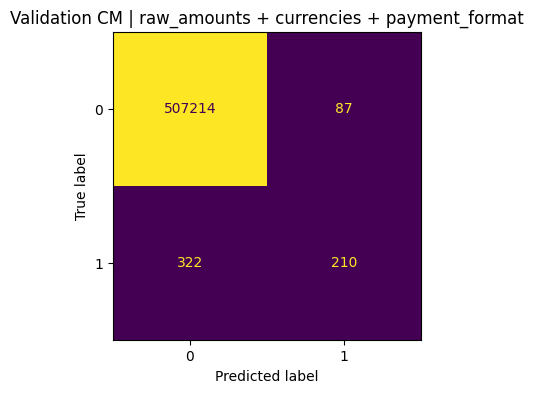

Feature set: raw_amounts + currencies + payment_format + time_basic
Val PR-AUC: 0.3851
Val ROC-AUC: 0.8980
Validation confusion matrix:
[[507246     55]
 [   357    175]]


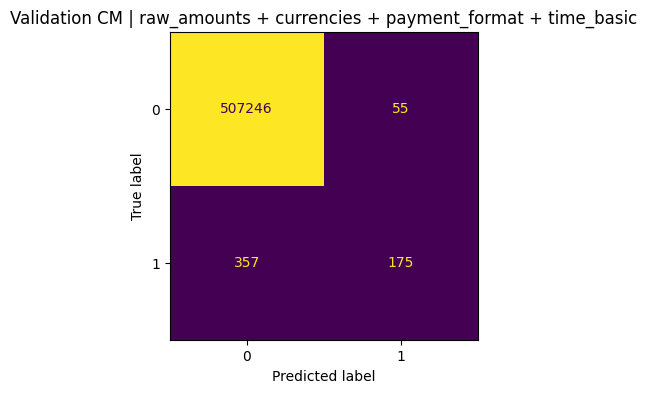

Feature set: raw_amounts + currencies + payment_format + time_cyclical
Val PR-AUC: 0.3956
Val ROC-AUC: 0.9149
Validation confusion matrix:
[[507212     89]
 [   322    210]]


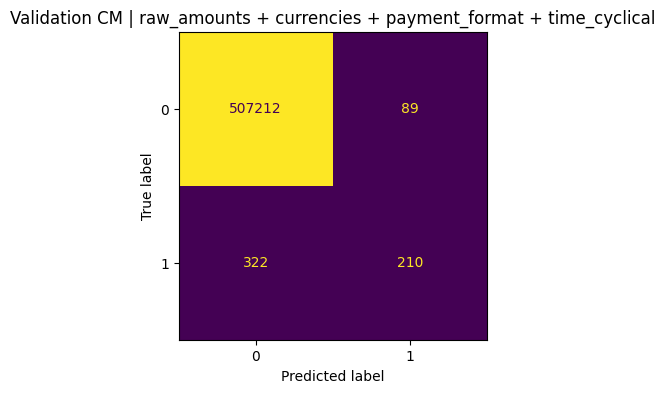

Feature set: raw_amounts + currencies + payment_format + time_trend
Val PR-AUC: 0.3949
Val ROC-AUC: 0.9170
Validation confusion matrix:
[[507188    113]
 [   320    212]]


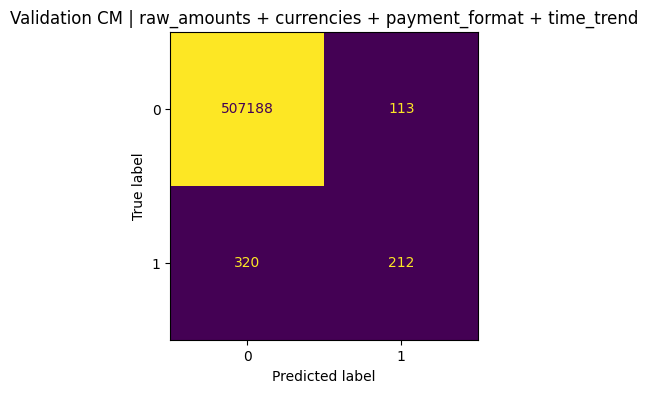

Feature set: raw_amounts + currencies + payment_format + time_basic + time_cyclical
Val PR-AUC: 0.3969
Val ROC-AUC: 0.9023
Validation confusion matrix:
[[507188    113]
 [   322    210]]


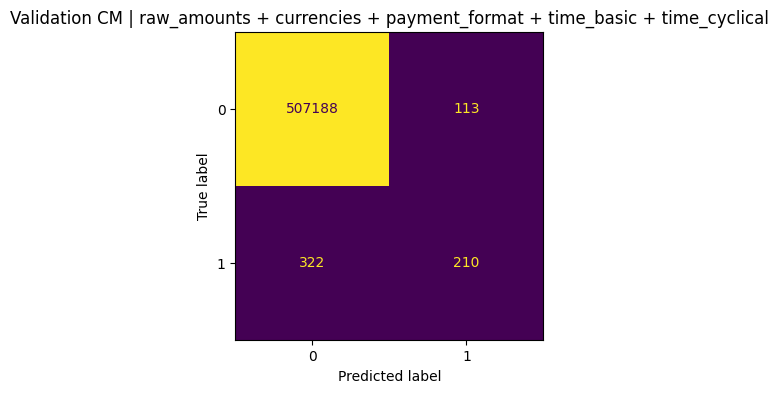

Feature set: raw_amounts + currencies + payment_format + time_basic + time_trend
Val PR-AUC: 0.3979
Val ROC-AUC: 0.9033
Validation confusion matrix:
[[507244     57]
 [   348    184]]


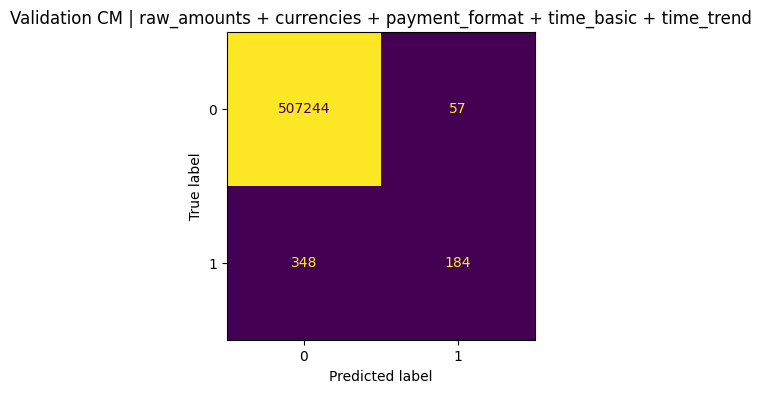

Feature set: raw_amounts + currencies + payment_format + time_cyclical + time_trend
Val PR-AUC: 0.3930
Val ROC-AUC: 0.9073
Validation confusion matrix:
[[507222     79]
 [   332    200]]


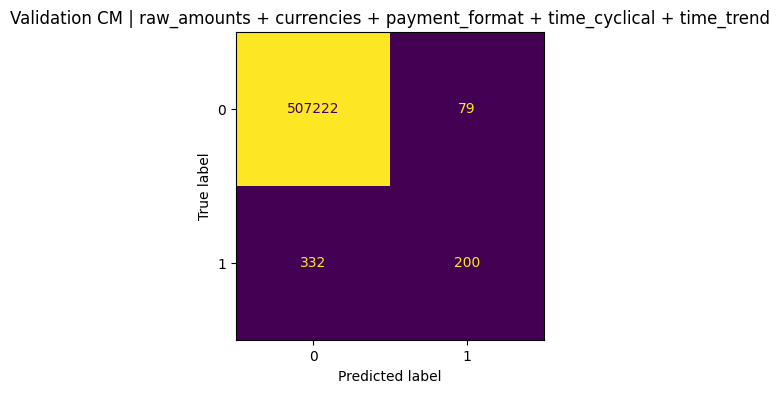

In [46]:
for r in all_results:
    if "val_confusion_matrix" not in r:
        continue

    print("=" * 80)
    print("Feature set:", r["feature_set"])
    print(f"Val PR-AUC: {r.get('val_pr_auc', np.nan):.4f}")
    print(f"Val ROC-AUC: {r.get('val_roc_auc', np.nan):.4f}")
    print("Validation confusion matrix:")
    print(r["val_confusion_matrix"])

    plot_confusion_matrix_from_array(
        r["val_confusion_matrix"],
        title=f"Validation CM | {r['feature_set']}"
    )

In [47]:
valid_results = [r for r in all_results if not pd.isna(r.get("val_pr_auc", np.nan))]
if len(valid_results) == 0:
    raise ValueError("No successful runs were completed.")

best_result = max(valid_results, key=lambda x: x["val_pr_auc"])

print("Best feature set by validation PR-AUC:")
print(best_result["feature_set"])
print()
print("Raw columns:")
print(best_result["feature_cols"])
print()
print("Expanded encoded columns:")
print(best_result["expanded_feature_names"])
print()
print("Validation PR-AUC:", best_result["val_pr_auc"])
print("Validation ROC-AUC:", best_result["val_roc_auc"])

Best feature set by validation PR-AUC:
raw_amounts + currencies + payment_format

Raw columns:
['Amount Received', 'Amount Paid', 'Log Amount Received', 'Receiving Currency', 'Payment Currency', 'Payment Format']

Expanded encoded columns:
['Amount Received', 'Amount Paid', 'Log Amount Received', 'Receiving Currency__US Dollar', 'Receiving Currency__Bitcoin', 'Receiving Currency__Euro', 'Receiving Currency__Australian Dollar', 'Receiving Currency__Yuan', 'Receiving Currency__Rupee', 'Receiving Currency__Mexican Peso', 'Receiving Currency__Yen', 'Receiving Currency__UK Pound', 'Receiving Currency__Ruble', 'Receiving Currency__Canadian Dollar', 'Receiving Currency__Swiss Franc', 'Receiving Currency__Brazil Real', 'Receiving Currency__Saudi Riyal', 'Receiving Currency__Shekel', 'Payment Currency__US Dollar', 'Payment Currency__Bitcoin', 'Payment Currency__Euro', 'Payment Currency__Australian Dollar', 'Payment Currency__Yuan', 'Payment Currency__Rupee', 'Payment Currency__Yen', 'Payment Cu

## GNN + CatBoost

In [48]:
FINAL_FEATURE_SET_NAME = best_result["feature_set"]
FINAL_FEATURE_COLS = [c for c in best_result["feature_cols"] if c in df.columns]
EXPECTED_GNN_NOTEBOOK_FEATURE_SET = "raw_amounts + currencies + payment_format + time_cyclical"

print("Final GNN + CatBoost feature set:", FINAL_FEATURE_SET_NAME)
print("Raw columns:", FINAL_FEATURE_COLS)
if FINAL_FEATURE_SET_NAME != EXPECTED_GNN_NOTEBOOK_FEATURE_SET:
    print("WARNING: feature search winner in this pipeline differs from the feature set used in 01_gnn_HI_Small.ipynb")


data_final, train_loader_final, val_loader_final, test_loader_final, expanded_feature_names_final = make_loaders_for_feature_cols(
    df=df,
    edge_index=edge_index,
    y_edge_t=y_edge_t,
    num_nodes=num_nodes,
    train_eids=train_eids,
    val_eids=val_eids,
    test_eids=test_eids,
    feature_cols=FINAL_FEATURE_COLS,
    num_neighbors=NUM_NEIGHBORS,
    batch_size=BATCH_SIZE,
)

EDGE_DIM_FINAL = data_final.edge_attr.size(1)
print("Expanded encoded columns:", expanded_feature_names_final)
print("EDGE_DIM_FINAL:", EDGE_DIM_FINAL)
print("GNN training split sizes -> train:", len(train_eids), "val:", len(val_eids), "test:", len(test_eids))


Final GNN + CatBoost feature set: raw_amounts + currencies + payment_format
Raw columns: ['Amount Received', 'Amount Paid', 'Log Amount Received', 'Receiving Currency', 'Payment Currency', 'Payment Format']
Expanded encoded columns: ['Amount Received', 'Amount Paid', 'Log Amount Received', 'Receiving Currency__US Dollar', 'Receiving Currency__Bitcoin', 'Receiving Currency__Euro', 'Receiving Currency__Australian Dollar', 'Receiving Currency__Yuan', 'Receiving Currency__Rupee', 'Receiving Currency__Mexican Peso', 'Receiving Currency__Yen', 'Receiving Currency__UK Pound', 'Receiving Currency__Ruble', 'Receiving Currency__Canadian Dollar', 'Receiving Currency__Swiss Franc', 'Receiving Currency__Brazil Real', 'Receiving Currency__Saudi Riyal', 'Receiving Currency__Shekel', 'Payment Currency__US Dollar', 'Payment Currency__Bitcoin', 'Payment Currency__Euro', 'Payment Currency__Australian Dollar', 'Payment Currency__Yuan', 'Payment Currency__Rupee', 'Payment Currency__Yen', 'Payment Currency_

In [49]:
final_gnn = EdgeAwareGNN(
    num_nodes=num_nodes,
    hidden=HIDDEN,
    edge_dim=EDGE_DIM_FINAL,
).to(device)

opt_final = torch.optim.Adam(final_gnn.parameters(), lr=LR)
crit_final = nn.CrossEntropyLoss()

final_history = []
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch_train(final_gnn, train_loader_final, opt_final, crit_final, device)
    va_loss, va_acc, _, va_pr, va_roc, _, _, _ = run_epoch_eval(
        final_gnn,
        val_loader_final,
        crit_final,
        device,
        max_batches=MAX_EVAL_BATCHES,
    )
    final_history.append({
        "epoch": epoch,
        "train_loss": tr_loss,
        "train_acc": tr_acc,
        "val_loss": va_loss,
        "val_acc": va_acc,
        "val_pr_auc": va_pr,
        "val_roc_auc": va_roc,
    })
    print(
        f"[Final GNN] epoch {epoch} | "
        f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
        f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
        f"val PR {va_pr:.4f} | val ROC {va_roc:.4f}"
    )

final_history_df = pd.DataFrame(final_history)
final_history_df

[Final GNN] epoch 1 | train loss 0.0082 acc 0.9979 | val loss 0.0056 acc 0.9991 | val PR 0.3322 | val ROC 0.8908
[Final GNN] epoch 2 | train loss 0.0040 acc 0.9993 | val loss 0.0050 acc 0.9993 | val PR 0.4287 | val ROC 0.9106
[Final GNN] epoch 3 | train loss 0.0028 acc 0.9994 | val loss 0.0055 acc 0.9992 | val PR 0.4112 | val ROC 0.8927


,epoch,train_loss,train_acc,val_loss,val_acc,val_pr_auc,val_roc_auc
0,1,0.008162,0.997925,0.005631,0.999118,0.332227,0.890831
1,2,0.003979,0.999260,0.005028,0.999264,0.428684,0.910579
2,3,0.002808,0.999384,0.005484,0.999232,0.411207,0.892666


{'model': 'Final_GNN', 'feature_set': 'raw_amounts + currencies + payment_format', 'val_pr_auc': np.float64(0.409776649553787), 'val_roc_auc': np.float64(0.8983781084246925), 'test_pr_auc': np.float64(0.4003104135849459), 'test_roc_auc': np.float64(0.8992836235889707)}


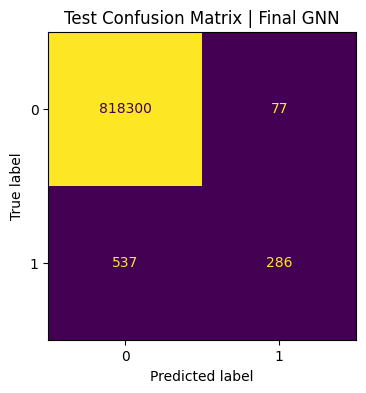

In [50]:
# Evaluate the trained GNN before stacking
_, _, _, gnn_val_pr_auc, gnn_val_roc_auc, gnn_val_cm, gnn_val_y, gnn_val_p = run_epoch_eval(
    final_gnn,
    val_loader_final,
    crit_final,
    device,
    max_batches=MAX_EVAL_BATCHES,
)
_, _, _, gnn_test_pr_auc, gnn_test_roc_auc, gnn_test_cm, gnn_test_y, gnn_test_p = run_epoch_eval(
    final_gnn,
    test_loader_final,
    crit_final,
    device,
    max_batches=MAX_EVAL_BATCHES,
)

gnn_final_metrics = {
    "model": "Final_GNN",
    "feature_set": FINAL_FEATURE_SET_NAME,
    "val_pr_auc": gnn_val_pr_auc,
    "val_roc_auc": gnn_val_roc_auc,
    "test_pr_auc": gnn_test_pr_auc,
    "test_roc_auc": gnn_test_roc_auc,
}

print(gnn_final_metrics)
plot_confusion_matrix_from_array(gnn_test_cm, "Test Confusion Matrix | Final GNN")


In [51]:
# Create node embeddings from the trained GNN exactly the same way as in 01_gnn_HI_Small.ipynb

def encode_batch(model, batch):
    x = model.emb(batch.n_id)
    x = F.relu(model.conv1(x, batch.edge_index, batch.edge_attr))
    x = model.conv2(x, batch.edge_index, batch.edge_attr)
    return x

hidden_final = HIDDEN  # must match the trained GNN hidden size
H_final = np.zeros((num_nodes, hidden_final), dtype=np.float32)

infer_loader_final = NeighborLoader(
    data_final,
    input_nodes=torch.arange(num_nodes),
    num_neighbors=[10, 5],
    batch_size=65536,
    shuffle=False,
    num_workers=2,
    persistent_workers=True
)

final_gnn.eval()
with torch.no_grad():
    for batch in infer_loader_final:
        batch = batch.to(device)
        z = encode_batch(final_gnn, batch).detach().cpu().numpy()
        H_final[batch.n_id.cpu().numpy()] = z

print("Embeddings stored in memory:", H_final.shape, "dtype:", H_final.dtype)


Embeddings stored in memory: (515088, 128) dtype: float32


In [52]:
# Build CatBoost tabular features from GNN node embeddings + edge features
# This block intentionally mirrors the temporal CatBoost split from 01_gnn_HI_Small.ipynb

def build_catboost_Xy(edge_ids, edge_index, edge_attr_t, y_edge_t, H):
    if hasattr(edge_ids, "detach"):
        edge_ids_np = edge_ids.detach().cpu().numpy()
    else:
        edge_ids_np = np.asarray(edge_ids)

    src = edge_index[0, edge_ids_np].detach().cpu().numpy()
    dst = edge_index[1, edge_ids_np].detach().cpu().numpy()

    hs = H[src]
    hd = H[dst]
    diff = np.abs(hs - hd)
    had = hs * hd
    eattr = edge_attr_t[edge_ids_np].detach().cpu().numpy()

    X = np.concatenate([hs, hd, diff, had, eattr], axis=1)
    y = y_edge_t[edge_ids_np].detach().cpu().numpy()
    return X, y

ts_cat = pd.to_datetime(df["_ts"], errors="coerce")
if ts_cat.isna().any():
    ts_cat = ts_cat.fillna(ts_cat.dropna().min())

order_cat = np.argsort(ts_cat.values.astype("datetime64[ns]"))
E_cat = len(order_cat)

cut_train_cat = int(0.70 * E_cat)
cut_val_cat = int(0.80 * E_cat)

train_eids_cat = order_cat[:cut_train_cat]
val_eids_cat = order_cat[cut_train_cat:cut_val_cat]
test_eids_cat = order_cat[cut_val_cat:]

y_np_cat = y_edge_t.detach().cpu().numpy()
train_pos_cat = train_eids_cat[y_np_cat[train_eids_cat] == 1]
train_neg_cat = train_eids_cat[y_np_cat[train_eids_cat] == 0]

print("Temporal CatBoost split pos rates -> train:", float(y_np_cat[train_eids_cat].mean()),
      "val:", float(y_np_cat[val_eids_cat].mean()),
      "test:", float(y_np_cat[test_eids_cat].mean()))
print("Temporal CatBoost split sizes -> train:", len(train_eids_cat),
      "val:", len(val_eids_cat), "test:", len(test_eids_cat))

neg_mult = 10
n_pos_cat = len(train_pos_cat)
if n_pos_cat == 0:
    raise ValueError("No positive edges in the temporal CatBoost train split.")

n_neg_cat = min(len(train_neg_cat), n_pos_cat * neg_mult)
rng_cat = np.random.default_rng(42)
train_neg_sample_cat = rng_cat.choice(train_neg_cat, size=n_neg_cat, replace=False)

train_sel_cat = np.concatenate([train_pos_cat, train_neg_sample_cat])
rng_cat.shuffle(train_sel_cat)

X_train, y_train = build_catboost_Xy(train_sel_cat, edge_index, data_final.edge_attr, y_edge_t, H_final)
X_val, y_val = build_catboost_Xy(val_eids_cat, edge_index, data_final.edge_attr, y_edge_t, H_final)
X_test, y_test = build_catboost_Xy(test_eids_cat, edge_index, data_final.edge_attr, y_edge_t, H_final)

print("CatBoost train shape:", X_train.shape, "val shape:", X_val.shape, "test shape:", X_test.shape)
print("Positive rates -> train:", float(y_train.mean()), "val:", float(y_val.mean()), "test:", float(y_test.mean()))


Temporal CatBoost split pos rates -> train: 0.0008034128166286199 val: 0.0010298661174047373 test: 0.0017702635113048752
Temporal CatBoost split sizes -> train: 3554835 val: 507833 test: 1015668
CatBoost train shape: (31416, 552) val shape: (507833, 552) test shape: (1015668, 552)
Positive rates -> train: 0.09090909090909091 val: 0.0010298661174047373 test: 0.0017702635113048752


In [53]:
# Train CatBoost on top of the GNN features
cb = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=200,
    task_type="CPU"
)

cb.fit(
    X_train, y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)

p_val_raw = cb.predict_proba(X_val)[:, 1]
p_test_raw = cb.predict_proba(X_test)[:, 1]

final_threshold = 0.5
final_test_pred = (p_test_raw >= final_threshold).astype(int)
final_test_cm = confusion_matrix(y_test, final_test_pred, labels=[0, 1])

cat_metrics = {
    "model": "GNN_plus_CatBoost",
    "feature_set": FINAL_FEATURE_SET_NAME,
    "catboost_split": "temporal_70_10_20",
    "val_pos_rate": float(y_val.mean()),
    "val_pr_auc": average_precision_score(y_val, p_val_raw),
    "val_roc_auc": roc_auc_score(y_val, p_val_raw),
    "test_pos_rate": float(y_test.mean()),
    "test_pr_auc": average_precision_score(y_test, p_test_raw),
    "test_roc_auc": roc_auc_score(y_test, p_test_raw),
}

print(cat_metrics)


0:	test: 0.9302255	best: 0.9302255 (0)	total: 201ms	remaining: 6m 41s
200:	test: 0.9829219	best: 0.9829295 (198)	total: 23.3s	remaining: 3m 28s
400:	test: 0.9841546	best: 0.9841922 (396)	total: 46.4s	remaining: 3m 4s
600:	test: 0.9842595	best: 0.9843559 (537)	total: 1m 9s	remaining: 2m 40s
800:	test: 0.9843821	best: 0.9843821 (800)	total: 1m 31s	remaining: 2m 17s
1000:	test: 0.9844183	best: 0.9844575 (901)	total: 1m 54s	remaining: 1m 53s
1200:	test: 0.9843353	best: 0.9844575 (901)	total: 2m 17s	remaining: 1m 31s
1400:	test: 0.9842728	best: 0.9844575 (901)	total: 2m 39s	remaining: 1m 8s
1600:	test: 0.9842859	best: 0.9844575 (901)	total: 3m 2s	remaining: 45.4s
1800:	test: 0.9843406	best: 0.9844575 (901)	total: 3m 24s	remaining: 22.6s
1999:	test: 0.9843081	best: 0.9844575 (901)	total: 3m 46s	remaining: 0us

bestTest = 0.9844574595
bestIteration = 901

Shrink model to first 902 iterations.
{'model': 'GNN_plus_CatBoost', 'feature_set': 'raw_amounts + currencies + payment_format', 'catboost_

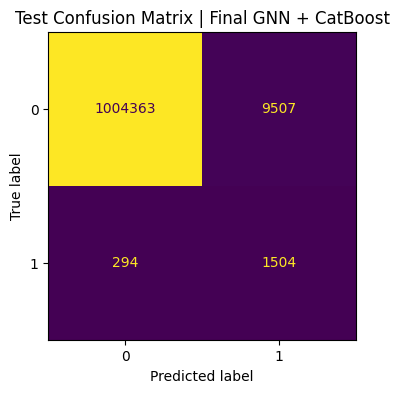

In [54]:
plot_confusion_matrix_from_array(final_test_cm, "Test Confusion Matrix | Final GNN + CatBoost")

In [55]:
final_model_summary = pd.DataFrame([
    {
        "model": gnn_final_metrics["model"],
        "feature_set": gnn_final_metrics["feature_set"],
        "val_pr_auc": gnn_final_metrics["val_pr_auc"],
        "val_roc_auc": gnn_final_metrics["val_roc_auc"],
        "test_pr_auc": gnn_final_metrics["test_pr_auc"],
        "test_roc_auc": gnn_final_metrics["test_roc_auc"],
    },
    {
        "model": cat_metrics["model"],
        "feature_set": cat_metrics["feature_set"],
        "val_pr_auc": cat_metrics["val_pr_auc"],
        "val_roc_auc": cat_metrics["val_roc_auc"],
        "test_pr_auc": cat_metrics["test_pr_auc"],
        "test_roc_auc": cat_metrics["test_roc_auc"],
    },
])

final_model_summary


,model,feature_set,val_pr_auc,val_roc_auc,test_pr_auc,test_roc_auc
0,Final_GNN,raw_amounts + currencies + payment_format,0.409777,0.898378,0.400310,0.899284
1,GNN_plus_CatBoost,raw_amounts + currencies + payment_format,0.506332,0.984457,0.632135,0.988413


# Model Performance

In [56]:
iso = IsotonicRegression(out_of_bounds="clip")

iso.fit(p_val_raw, y_val)

p_val_cal = iso.transform(p_val_raw)
p_test_cal = iso.transform(p_test_raw)

print("Calibration complete")

Calibration complete


In [57]:
p_test_cal

array([1.76056338e-03, 3.49650350e-04, 2.61318351e-04, ...,
       8.25000000e-01, 7.05882353e-01, 5.71428571e-01])

In [58]:
print("Raw Brier:", brier_score_loss(y_test, p_test_raw))
print("Calibrated Brier:", brier_score_loss(y_test, p_test_cal))

Raw Brier: 0.007831845263548
Calibrated Brier: 0.0009247454404267207


In [59]:
results = pd.DataFrame({
    "edge_id": test_eids_cat,
    "timestamp": ts_cat.iloc[test_eids_cat].values,
    "label": y_test,
    "score_raw": p_test_raw,
    "risk_prob": p_test_cal
})

results = results.sort_values("risk_prob", ascending=False)

results.head(10)


,edge_id,timestamp,label,score_raw,risk_prob
1014719,4982400,2022-09-11 11:46:00,1,0.999905,1.0
317033,1854522,2022-09-09 05:38:00,1,0.999937,1.0
455731,4127854,2022-09-09 10:49:00,1,0.999885,1.0
887816,4510168,2022-09-10 08:10:00,1,0.999899,1.0
1014707,4550041,2022-09-11 11:27:00,1,0.999888,1.0
137709,4198160,2022-09-08 23:16:00,1,0.999936,1.0
570428,2387739,2022-09-09 15:08:00,1,0.999960,1.0
1015091,4059241,2022-09-12 12:19:00,1,0.999877,1.0
145714,3805124,2022-09-08 23:41:00,1,0.999923,1.0
599426,3961345,2022-09-09 16:14:00,1,0.999906,1.0


In [60]:
results["date"] = pd.to_datetime(results["timestamp"]).dt.date

alerts_per_day = results.groupby("date").size().reset_index(name="alerts")

alerts_per_day.head()

,date,alerts
0,2022-09-08,151772
1,2022-09-09,654463
2,2022-09-10,208325
3,2022-09-11,396
4,2022-09-12,281


In [61]:
top500 = results.sort_values("risk_prob", ascending=False).head(500)

true_cases = top500["label"].sum()

precision_at_500 = true_cases / 500

print("True laundering cases in top 500:", true_cases)
print("Precision@500:", precision_at_500)

True laundering cases in top 500: 459
Precision@500: 0.918


In [62]:
total_laundering = results["label"].sum()

recall_at_500 = true_cases / total_laundering

print("Total laundering transactions:", total_laundering)
print("Recall@500:", recall_at_500)

Total laundering transactions: 1798
Recall@500: 0.25528364849833146
